# Training and Evaluating a Two-Tower Model in PyTorch

This notebook demonstrates how to build, train, and evaluate a basic two-tower model for recommendation systems.


- Setup

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 200)

- Download the raw data

In [3]:
RATINGS_URL = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv"
BOOKS_URL   = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/books.csv"

print("Downloading ratings...")
ratings = pd.read_csv(RATINGS_URL)   # ~69MB, user_id, book_id, rating
print("Downloading books...")
books = pd.read_csv(BOOKS_URL)       # metadata for each book

# Quick peek at data shape + a few rows
print("ratings:", ratings.shape)
print("books:", books.shape)

display(ratings.head())
display(books.head())

ratings: (5976479, 3)
books: (10000, 23)


,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [4]:
books.columns.tolist()

['book_id',
 'goodreads_book_id',
 'best_book_id',
 'work_id',
 'books_count',
 'isbn',
 'isbn13',
 'authors',
 'original_publication_year',
 'original_title',
 'title',
 'language_code',
 'average_rating',
 'ratings_count',
 'work_ratings_count',
 'work_text_reviews_count',
 'ratings_1',
 'ratings_2',
 'ratings_3',
 'ratings_4',
 'ratings_5',
 'image_url',
 'small_image_url']

In [5]:
ratings.columns.tolist()

['user_id', 'book_id', 'rating']

In [6]:
print(ratings["rating"].value_counts().sort_index())

rating
1     124195
2     359257
3    1370916
4    2139018
5    1983093
Name: count, dtype: int64


- Create toy dataset

In [7]:
# -----------------------------
# 1) Filter users by activity
# -----------------------------
# Count ratings per user
user_counts = ratings["user_id"].value_counts()

# Keep users with between 10 and 1000 ratings for a denser, more stable toy dataset
active_users = user_counts[(user_counts >= 10) & (user_counts <= 1000)].index

# Filter the ratings table down to those users
mini = ratings[ratings["user_id"].isin(active_users)].copy()

# -----------------------------
# 2) Filter books by popularity
# -----------------------------
# Count ratings per book within the filtered user subset
book_counts = mini["book_id"].value_counts()

# Keep books with at least 50 interactions in this subset
popular_books = book_counts[book_counts >= 50].index

# Filter again
mini = mini[mini["book_id"].isin(popular_books)].copy()

# -----------------------------
# 3) Label: Convert rating → implicit like if rating >= 4
# -----------------------------
mini["label"] = (mini["rating"] >= 4).astype("int8")

- Feature eng

In [8]:
# -----------------------------
# 4) Keep only book columns we want + feature engineering
# -----------------------------
book_feats = books[["book_id", "original_publication_year", "language_code", "authors"]].copy()

# Keep a small set of metadata columns we want to use as item features
book_feats = books[["book_id", "original_publication_year", "language_code", "authors"]].copy()

# Ensure publication year is numeric; non-numeric becomes NaN
book_feats["original_publication_year"] = pd.to_numeric(
    book_feats["original_publication_year"], errors="coerce"
)

# Bucket year by decade: e.g., 1999 -> 1990, 2003 -> 2000
book_feats["year_bucket"] = (
    (book_feats["original_publication_year"] // 10) * 10
)

# Extract a single "primary author" by taking the first in the comma-separated list
book_feats["primary_author"] = (
    book_feats["authors"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

# -----------------------------
# 5) Merge book metadata (year + language + author)
# -----------------------------
mini = mini.merge(book_feats, on="book_id", how="left")

# -----------------------------
# 6) Fill missing language/year AFTER merge
# -----------------------------

mini["language_code"] = (
    mini["language_code"]
    .fillna("UNK")
    .astype(str)
    .str.strip()
)
mini.loc[mini["language_code"] == "", "language_code"] = "UNK"

# Year bucket: add explicit UNK bucket for missing (fine to fill here)
mini["year_bucket"] = mini["year_bucket"].fillna(-1).astype(np.int32)

# build author vocabulary
mini["primary_author"] = (
    mini["primary_author"]
    .fillna("UNK")
    .astype(str)
)

# -----------------------------
# 7) Encodings
# -----------------------------
# e.g. encode language to integer ids (0..num_langs-1)
mini["lang_idx"] = mini["language_code"].astype("category").cat.codes.astype(np.int64)
mini["user_idx"] = mini["user_id"].astype("category").cat.codes.astype(np.int64)
mini["item_idx"] = mini["book_id"].astype("category").cat.codes.astype(np.int64)
mini["year_idx"] = mini["year_bucket"].astype("category").cat.codes.astype(np.int64)

author_to_idx = {a: i for i, a in enumerate(mini["primary_author"].unique())}
mini["author_idx"] = mini["primary_author"].map(author_to_idx).astype(np.int64)

display(mini.head())

,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author,lang_idx,user_idx,item_idx,year_idx,author_idx
0,1,258,5,1,2001.0,eng,"Carlos Ruiz Zafón, Lucia Graves",2000,Carlos Ruiz Zafón,7,0,257,82,0
1,2,4081,4,1,2004.0,en-US,Tom Wolfe,2000,Tom Wolfe,6,1,4079,82,1
2,2,260,5,1,1936.0,eng,Dale Carnegie,1930,Dale Carnegie,7,1,259,75,2
3,2,9296,5,1,1979.0,en-GB,"Alice Miller, Ruth Ward",1970,Alice Miller,5,1,9291,79,3
4,2,2318,3,0,1995.0,eng,"Thomas J. Stanley, William D. Danko",1990,Thomas J. Stanley,7,1,2316,81,4


- Stats

In [9]:
# -----------------------------
# 8) Display stats
# -----------------------------

num_users = mini["user_idx"].nunique()
num_items = mini["item_idx"].nunique()
num_langs = mini["lang_idx"].nunique()
num_authors = mini["author_idx"].nunique()
num_year_buckets = mini["year_idx"].nunique()
num_interactions = len(mini)

positives = (mini["label"] == 1).sum()
positive_rate = (mini["label"] == 1).mean()

unique_user_ids = mini["user_id"].nunique()
unique_book_ids = mini["book_id"].nunique()

# --- build stats dict + DataFrame ---
stats = {
    "num_users": num_users,
    "num_items": num_items,
    "num_langs": num_langs,
    "num_authors": num_authors,
    "num_year_buckets": num_year_buckets,
    "num_interactions": num_interactions,
    "positives": positives,
    "positive_rate": positive_rate,
    "unique_user_ids": unique_user_ids,
    "unique_book_ids": unique_book_ids,
}

stats_df = pd.DataFrame(stats, index=["value"]).T.astype(str)

# --- pretty formatting ---
for col in set(stats.keys()).difference({"positive_rate"}):
    stats_df.loc[col, "value"] = f"{stats[col]:,}"
stats_df.loc["positive_rate", "value"] = f"{positive_rate:.3f}"

display(stats_df)

,value
num_users,"53,424"
num_items,"9,991"
num_langs,26
num_authors,"3,883"
num_year_buckets,84
num_interactions,"5,976,185"
positives,"4,121,910"
positive_rate,0.690
unique_user_ids,"53,424"
unique_book_ids,"9,991"


- Train val test split

In [10]:
from sklearn.model_selection import train_test_split

seed = 42

# Create training set (80% of data)
train_df, temp_df = train_test_split(
    mini,
    test_size=0.2,
    random_state=seed,
    stratify=mini["label"],
)

# Create validation and testing set from equal halves of the remaining 20% of data
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=seed,
    stratify=temp_df["label"],
)

print(len(train_df), len(val_df), len(test_df))

display(train_df.head(5))

4780948 597618 597619


,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author,lang_idx,user_idx,item_idx,year_idx,author_idx
5372341,29442,238,4,1,2002.0,en-US,Augusten Burroughs,2000,Augusten Burroughs,6,29441,237,82,81
4981516,51427,4889,4,1,2012.0,en-US,Kim Harrison,2010,Kim Harrison,6,51426,4887,83,952
3963635,45159,894,4,1,1989.0,eng,Terry Pratchett,1980,Terry Pratchett,7,45158,893,80,438
4774535,45758,302,3,0,2010.0,eng,Nicholas Sparks,2010,Nicholas Sparks,7,45757,301,83,550
4257552,34843,607,3,0,2014.0,eng,Cassandra Clare,2010,Cassandra Clare,7,34842,606,83,1673


- Torch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import random

class GoodreadsTwoTowerDataset(Dataset):
    def __init__(
        self,
        df_pos,
        user_to_pos_set,
        num_items,
        num_neg=5,
        seed=42):
        # df_pos should be ONLY positives (label==1)
        self.users = df_pos["user_idx"].values
        self.pos_items = df_pos["item_idx"].values

        self.user_to_pos = user_to_pos_set
        self.num_items = int(num_items)
        self.num_neg = int(num_neg)

        # deterministic-ish per worker
        self.rng = random.Random(seed)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        i_pos = int(self.pos_items[idx])

        pos_set = self.user_to_pos.get(u, set())

        negs = []
        # safety cap to avoid infinite loop (shouldn't happen but protects you)
        tries = 0
        while len(negs) < self.num_neg and tries < 1000:
            j = self.rng.randrange(self.num_items)
            if j not in pos_set and j != i_pos:
                negs.append(j)
            tries += 1

        if len(negs) < self.num_neg:
            # fallback: allow duplicates if user has almost all items (extremely rare)
            while len(negs) < self.num_neg:
                negs.append(self.rng.randrange(self.num_items))

        return {
            "user_id": torch.tensor(u, dtype=torch.long),
            "pos_item_id": torch.tensor(i_pos, dtype=torch.long),
            "neg_item_id": torch.tensor(negs, dtype=torch.long),  # [num_neg]
        }

# ---- Train loader ----

train_pos_df = train_df[train_df["label"] == 1].copy()

user_to_train_pos = (
    train_pos_df.groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

train_dataset = GoodreadsTwoTowerDataset(
    df_pos=train_pos_df,
    user_to_pos_set=user_to_train_pos,
    num_items=num_items,
    num_neg=10,   # try 5-20
    seed=42,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

# sanity check
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})
print({k: v.dtype for k, v in batch.items()})

{'user_id': torch.Size([1024]), 'pos_item_id': torch.Size([1024]), 'neg_item_id': torch.Size([1024, 10])}
{'user_id': torch.int64, 'pos_item_id': torch.int64, 'neg_item_id': torch.int64}


- Define a TwoTower Model

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class TwoTowerModel(nn.Module):
    def __init__(
        self,
        num_users: int,
        num_items: int,
        num_langs: int,
        num_year_buckets: int,
        num_authors: int,
        emb_dim: int = 64,
        lang_emb_dim: int = 4,
        year_emb_dim: int = 4,
        author_emb_dim: int = 8,
    ):
        super().__init__()

        # ---- ID embeddings ----
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        # ---- Bias terms (KEY ADDITION) ----
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)

        # ---- Metadata embeddings ----
        self.lang_emb = nn.Embedding(num_langs, lang_emb_dim)
        self.year_emb = nn.Embedding(num_year_buckets, year_emb_dim)
        self.author_emb = nn.Embedding(num_authors, author_emb_dim)

        # ---- Project metadata → item embedding space ----
        self.item_feat = nn.Sequential(
            nn.Linear(lang_emb_dim + year_emb_dim + author_emb_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64, emb_dim),
        )

        # ---- Scaled dot product ----
        self.scale = math.sqrt(emb_dim)

        # ---- Bias initialization (important) ----
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    # -----------------------------
    # Encoders
    # -----------------------------
    def encode_user(self, user_ids: torch.Tensor) -> torch.Tensor:
        return self.user_emb(user_ids)                 # [B, D]

    def encode_item(
        self,
        item_ids: torch.Tensor,
        lang_ids: torch.Tensor,
        year_ids: torch.Tensor,
        author_ids: torch.Tensor,
    ) -> torch.Tensor:
        v_id = self.item_emb(item_ids)                 # [B, D]
        v_lang = self.lang_emb(lang_ids)               # [B, L]
        v_year = self.year_emb(year_ids)               # [B, Y]
        v_author = self.author_emb(author_ids)         # [B, A]

        x = torch.cat([v_lang, v_year, v_author], dim=-1)        # [B, L+Y+A]
        v_feat = self.item_feat(x)                     # [B, D]

        return v_id + v_feat                           # [B, D]

    # -----------------------------
    # Forward
    # -----------------------------
    def forward(
        self,
        user_ids: torch.Tensor,
        item_ids: torch.Tensor,
        lang_ids: torch.Tensor,
        year_ids: torch.Tensor,
        author_ids: torch.Tensor,
    ) -> torch.Tensor:
        u = self.encode_user(user_ids)                 # [B, D]
        v = self.encode_item(item_ids, lang_ids, year_ids, author_ids)

        dot = (u * v).sum(dim=-1) / self.scale         # [B]

        bu = self.user_bias(user_ids).squeeze(-1)      # [B]
        bi = self.item_bias(item_ids).squeeze(-1)      # [B]

        return dot + bu + bi

- Recall @ K for Evaluation

In [ ]:
@torch.no_grad()
def recall_at_k_mask_seen(
    model,
    eval_pos,
    train_seen,
    num_items,
    item_lang_ids,
    item_year_ids,
    item_author_ids,
    K=20,
    device="cpu",
    max_users=None,
):
    model.eval()

    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)

    all_item_ids = torch.arange(num_items, device=device, dtype=torch.long)

    # item embeddings + item bias
    all_item_embs = model.encode_item(all_item_ids, item_lang_ids, item_year_ids, item_author_ids)  # [I,D]
    all_item_bias = model.item_bias(all_item_ids).squeeze(-1)                      # [I]

    users = list(eval_pos.keys())
    if max_users is not None:
        users = users[:max_users]

    recalls = []
    for u in users:
        pos_set = eval_pos.get(u, set())
        if not pos_set:
            continue

        user_id = torch.tensor([u], device=device, dtype=torch.long)
        user_emb = model.encode_user(user_id)                                      # [1,D]
        user_b   = model.user_bias(user_id).squeeze(-1)                            # [1]

        # dot part (scaled)
        scores = (user_emb @ all_item_embs.T).squeeze(0) / model.scale             # [I]

        # add biases (broadcast user bias)
        scores = scores + all_item_bias + user_b

        # mask seen items
        seen = train_seen.get(u, set())
        if seen:
            seen_idx = torch.tensor(list(seen), device=device, dtype=torch.long)
            scores[seen_idx] = -1e9

        topk = torch.topk(scores, K, largest=True).indices.tolist()

        hits = sum((i in pos_set) for i in topk)
        recalls.append(hits / len(pos_set))

    return float(sum(recalls) / len(recalls)) if recalls else 0.0


In [ ]:
device

device(type='cuda')

In [ ]:
# Check ALL vocab sizes
checks = [
    ("Users", train_df['user_idx'].max(), num_users),
    ("Items", train_df['item_idx'].max(), num_items),
    ("Langs", train_df['lang_idx'].max(), num_langs),
    ("Years", train_df['year_idx'].max(), num_year_buckets),
    ("Authors", train_df['author_idx'].max(), num_authors)
]

for name, max_id, vocab in checks:
    print(f"{name}: Max ID {max_id}, Vocab {vocab}")
    if max_id >= vocab:
        print(f"!!! CRITICAL ERROR: {name} ID {max_id} is out of bounds for vocab {vocab}")

Users: Max ID 53423, Vocab 53424
Items: Max ID 9990, Vocab 9991
Langs: Max ID 25, Vocab 26
Years: Max ID 83, Vocab 84
Authors: Max ID 3882, Vocab 3883


In [ ]:
train_df["user_idx"].min(), train_df["item_idx"].min()

(0, 0)

In [ ]:
train_df["user_idx"].max(), train_df["item_idx"].max()

(53423, 9990)

In [ ]:
train_df.head()

,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author,lang_idx,user_idx,item_idx,year_idx,author_idx
5372341,29442,238,4,1,2002.0,en-US,Augusten Burroughs,2000,Augusten Burroughs,6,29441,237,82,81
4981516,51427,4889,4,1,2012.0,en-US,Kim Harrison,2010,Kim Harrison,6,51426,4887,83,952
3963635,45159,894,4,1,1989.0,eng,Terry Pratchett,1980,Terry Pratchett,7,45158,893,80,438
4774535,45758,302,3,0,2010.0,eng,Nicholas Sparks,2010,Nicholas Sparks,7,45757,301,83,550
4257552,34843,607,3,0,2014.0,eng,Cassandra Clare,2010,Cassandra Clare,7,34842,606,83,1673


- Run training loop

$$ \mathcal{L} = -\log \frac{ \exp(s^+ / \tau)}{\sum_{j=0}^{K} \exp(s_j / \tau)} $$


Using device: cuda
eval users: 53014 train users: 53424
Epoch 01 | loss: 2.0711 | masked recall@20: 0.0814
Epoch 02 | loss: 1.5003 | masked recall@20: 0.1053
Epoch 03 | loss: 1.2300 | masked recall@20: 0.1180
Epoch 04 | loss: 1.0846 | masked recall@20: 0.1216
Epoch 05 | loss: 1.0358 | masked recall@20: 0.1243


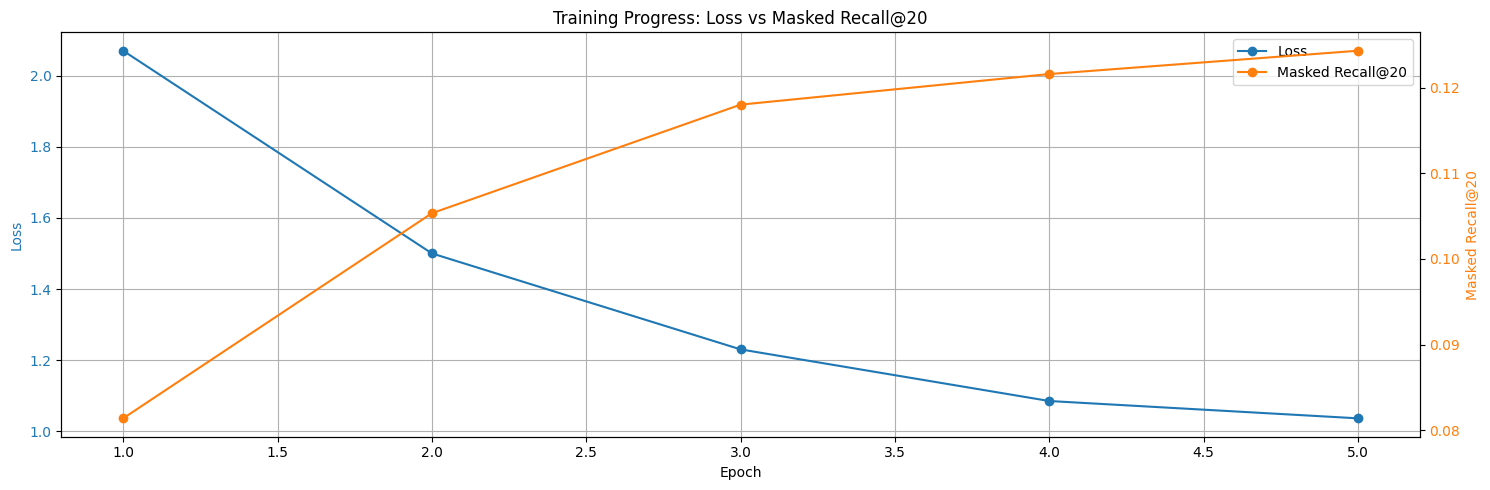

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ---- training fn ----
def train(
    model,
    dataloader,
    optimizer,
    device,
    item_lang_ids,
    item_year_ids,
    item_author_ids,
    info_nce=True,
    temperature=1,
):

    model.train()
    total = 0.0
    n = 0

    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)


    for batch in dataloader:
        u = batch["user_id"].to(device)                 # [B]
        i_pos = batch["pos_item_id"].to(device)         # [B]
        i_neg = batch["neg_item_id"].to(device)         # [B, Nneg]

        pos_lang = item_lang_ids[i_pos]                 # [B]
        pos_year = item_year_ids[i_pos]                 # [B]
        pos_author = item_author_ids[i_pos]             # [B]
        neg_lang = item_lang_ids[i_neg]                 # [B, Nneg]
        neg_year = item_year_ids[i_neg]                 # [B, Nneg]
        neg_author_id = item_author_ids[i_neg]          # [B, Nneg]

        optimizer.zero_grad(set_to_none=True)

        # -- scores --
        s_pos = model(u, i_pos, pos_lang, pos_year, pos_author)     # [B]

        # epxand users to match negatives
        u_neg = u.unsqueeze(1).expand_as(i_neg)         # [B, Nneg]
        s_neg = model(u_neg, i_neg, neg_lang, neg_year, neg_author_id) # [B, Nneg]

        # sampled softmax / InfoNCE loss
        # candidate scores: [B, 1+Nneg], true class index is 0 (the positive)

        if not info_nce:
            loss = -F.logsigmoid(s_pos.unsqueeze(1) - s_neg).mean()
        else:
            scores = torch.cat([s_pos.unsqueeze(1), s_neg], dim=1)  # [B, 1+Nneg]
            scores = scores / temperature
            targets = torch.zeros(scores.size(0), dtype=torch.long, device=device)
            loss = F.cross_entropy(scores, targets)

        loss.backward()
        optimizer.step()

        total += loss.item()
        n += 1

    return total / max(n, 1)


# ---- device ----
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# ---- item-level metadata tensors (aligned to item_idx) ----
item_meta = (
    mini[["item_idx", "lang_idx", "year_idx", "author_idx"]]
    .drop_duplicates("item_idx")
    .sort_values("item_idx")
)

item_lang_ids = torch.tensor(item_meta["lang_idx"].values, dtype=torch.long)
item_year_ids = torch.tensor(item_meta["year_idx"].values, dtype=torch.long)
item_author_ids = torch.tensor(item_meta["author_idx"].values, dtype=torch.long)

num_users = int(mini["user_idx"].nunique())
num_items = int(mini["item_idx"].nunique())
num_langs = int(mini["lang_idx"].nunique())
num_year_buckets = int(mini["year_idx"].nunique())
num_authors = int(mini["author_idx"].nunique())

assert len(item_meta) == num_items
assert (item_meta["item_idx"].values == torch.arange(num_items).numpy()).all()

# -----------------------------
# 1) Build train_seen and eval_pos
# -----------------------------
train_seen = (
    train_df.groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

# choose split to evaluate on
eval_df = val_df   # <-- change to test_df when model is trained

eval_pos = (
    eval_df[eval_df["label"] == 1]
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

print("eval users:", len(eval_pos), "train users:", len(train_seen))

# ---- model ----

model = TwoTowerModel(
    num_users=num_users,
    num_items=num_items,
    num_langs=num_langs,
    num_year_buckets=num_year_buckets,
    num_authors=num_authors,
    emb_dim=64,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ---- loop ----
num_epochs = 5
losses = []
recall20s  = []

# choose split to evaluate on
eval_df = val_df   # <-- change to val_df if you want validation

eval_pos = (
    eval_df[eval_df["label"] == 1]
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

for epoch in range(1, num_epochs + 1):
    loss = train(
        model,
        train_loader,
        optimizer,
        device,
        item_lang_ids,
        item_year_ids,
        item_author_ids,
        info_nce=True,
    )

    r20 = recall_at_k_mask_seen(
        model,
        eval_pos,
        train_seen,
        num_items,
        item_lang_ids,
        item_year_ids,
        item_author_ids,
        K=20,
        device=device,
        max_users=2000,
    )

    losses.append(loss)
    recall20s.append(r20)

    print(f"Epoch {epoch:02d} | loss: {loss:.4f} | masked recall@20: {r20:.4f}")

# ---- plot (two y-axes since scales differ) ----
epochs = list(range(1, num_epochs + 1))
fig, ax1 = plt.subplots(figsize=(15, 5))

# Left axis: Loss
color_loss = "tab:blue"
ax1.plot(epochs, losses, color=color_loss, marker="o", label="Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color_loss)
ax1.tick_params(axis="y", labelcolor=color_loss)
ax1.grid(True)

# Right axis: Recall@20
ax2 = ax1.twinx()
color_recall = "tab:orange"
ax2.plot(epochs, recall20s, color=color_recall, marker="o", label="Masked Recall@20")
ax2.set_ylabel("Masked Recall@20", color=color_recall)
ax2.tick_params(axis="y", labelcolor=color_recall)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Training Progress: Loss vs Masked Recall@20")
plt.tight_layout()
plt.show()

- Evaluate

In [ ]:
import numpy as np
import torch

def recall_at_k_pop_mask_seen(eval_pos, train_seen, popular_items, K=20, max_users=None):
    users = list(eval_pos.keys())
    if max_users is not None:
        users = users[:max_users]

    recalls = []
    for u in users:
        pos_set = eval_pos.get(u, set())
        if not pos_set:
            continue

        seen = train_seen.get(u, set())

        recs = []
        for it in popular_items:
            if it not in seen:
                recs.append(it)
            if len(recs) >= K:
                break

        hits = sum((i in pos_set) for i in recs)
        recalls.append(hits / len(pos_set))

    return float(sum(recalls) / len(recalls)) if recalls else 0.0

# -----------------------------
# 1) Build train_seen and eval_pos
# -----------------------------
train_seen = (
    train_df.groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

# choose split to evaluate on
eval_df = test_df   # <-- change to val_df if you want validation

eval_pos = (
    eval_df[eval_df["label"] == 1]
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)


# -----------------------------
# 2) Popularity list from TRAIN positives (global)
# -----------------------------
popular_items = (
    train_df[train_df["label"] == 1]
    .groupby("item_idx")
    .size()
    .sort_values(ascending=False)
    .index.tolist()
)


# -----------------------------
# 4) Compute both metrics on SAME users (cap optional)
# -----------------------------
MAX_USERS = 2000  # set None for all users (slower but best)

model_r20 = recall_at_k_mask_seen(
    model=model,
    eval_pos=eval_pos,
    train_seen=train_seen,
    num_items=num_items,
    item_lang_ids=item_lang_ids,
    item_year_ids=item_year_ids,
    item_author_ids=item_author_ids,
    K=20,
    device=device,
    max_users=MAX_USERS,
)

pop_r20 = recall_at_k_pop_mask_seen(
    eval_pos=eval_pos,
    train_seen=train_seen,
    popular_items=popular_items,
    K=20,
    max_users=MAX_USERS,
)

print(f"Masked Recall@20 (Model): {model_r20:.4f}")
print(f"Masked Recall@20 (Pop)  : {pop_r20:.4f}")
print(f"Lift (abs): {model_r20 - pop_r20:+.4f}")
print(f"Lift (rel): {(model_r20 / pop_r20 - 1.0)*100:+.2f}%")

Masked Recall@20 (Model): 0.1228
Masked Recall@20 (Pop)  : 0.0809
Lift (abs): +0.0420
Lift (rel): +51.90%


- Inspect model

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def inspect_5_users(
    model,
    train_df,
    eval_df,                 # val_df or test_df
    item_info,               # from above
    item_lang_ids,           # torch.LongTensor [num_items]
    item_year_ids,           # torch.LongTensor [num_items]
    item_author_ids,         # torch.LongTensor [num_items]
    num_items,
    K=10,
    n_users=5,
    device="cpu",
    seed=42,
):
    model.eval()

    train_pos = (
        train_df[train_df["label"] == 1]
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )
    eval_pos = (
        eval_df[eval_df["label"] == 1]
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )

    users = list(eval_pos.keys())
    if not users:
        print("No eval positives to inspect.")
        return

    rng = np.random.default_rng(seed)
    chosen = rng.choice(users, size=min(n_users, len(users)), replace=False).tolist()

    # Precompute all item embeddings once
    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)
    all_item_ids = torch.arange(num_items, device=device, dtype=torch.long)
    all_item_embs = model.encode_item(all_item_ids, item_lang_ids, item_year_ids, item_author_ids)  # [I, D]

    info = item_info.set_index("item_idx")

    def fmt(i):
        r = info.loc[i]
        return f'{int(r.book_id)} | {str(r.title)[:80]} | lang={r.language_code} | year_bucket={r.year_bucket}'

    for u in chosen:
        seen = train_pos.get(u, set())
        held = eval_pos.get(u, set())

        user_id = torch.tensor([u], device=device, dtype=torch.long)
        user_emb = model.encode_user(user_id)  # [1,D]

        scores = (user_emb @ all_item_embs.T).squeeze(0) / model.scale

        # mask train-seen
        if seen:
            scores[torch.tensor(list(seen), device=device, dtype=torch.long)] = -1e9

        topk = torch.topk(scores, K, largest=True).indices.detach().cpu().tolist()
        hits = [i for i in topk if i in held]

        print("\n" + "="*100)
        print(f"user_idx={u} | train_pos={len(seen)} | eval_pos={len(held)} | hits_in_top{K}={len(hits)}")

        print("\nTrain history (first 15 positives):")
        for i in list(seen)[:15]:
            print("  H ", fmt(i))

        print(f"\nTop-{K} recommendations (masked train-seen):")
        for rank, i in enumerate(topk, 1):
            mark = "✅" if i in held else "  "
            print(f"  {mark} #{rank:02d} {fmt(i)}")

        print("\nHeld-out eval positives (first 15):")
        for i in list(held)[:15]:
            print("  T ", fmt(i))

    print("\nDone.")


# Map item_idx -> (book_id, title, language_code, year_bucket)
item_info = (
    mini[["item_idx", "book_id", "language_code", "year_bucket", "primary_author"]]
    .drop_duplicates("item_idx")
    .merge(books[["book_id", "title"]], on="book_id", how="left")
    .sort_values("item_idx")
)

inspect_5_users(
    model=model,
    train_df=train_df,
    eval_df=val_df,              # or test_df
    item_info=item_info,
    item_lang_ids=item_lang_ids,
    item_year_ids=item_year_ids,
    item_author_ids=item_author_ids,
    num_items=num_items,
    K=10,
    n_users=5,
    device=device,
    seed=42,
)


user_idx=41314 | train_pos=69 | eval_pos=11 | hits_in_top10=0

Train history (first 15 positives):
  H  1 | The Hunger Games (The Hunger Games, #1) | lang=eng | year_bucket=2000
  H  4611 | Romancing Mister Bridgerton (Bridgertons, #4) | lang=eng | year_bucket=2000
  H  2 | Harry Potter and the Sorcerer's Stone (Harry Potter, #1) | lang=eng | year_bucket=1990
  H  7301 | To Sir Phillip, With Love (Bridgertons, #5) | lang=eng | year_bucket=2000
  H  134 | City of Glass (The Mortal Instruments, #3) | lang=en-US | year_bucket=2000
  H  5383 | Darkest Hour (The Mediator, #4) | lang=eng | year_bucket=2000
  H  4234 | Twilight (The Mediator, #6) | lang=eng | year_bucket=2000
  H  5899 | An Offer From a Gentleman (Bridgertons, #3) | lang=en-US | year_bucket=2000
  H  5372 | Reunion (The Mediator, #3) | lang=eng | year_bucket=2000
  H  12 | Divergent (Divergent, #1) | lang=eng | year_bucket=2010
  H  5517 | Every Boy's Got One (Boy, #3) | lang=en-GB | year_bucket=2000
  H  2319 | Don't Judge 

In [ ]:
author_counts = train_df[train_df["label"]==1]["author_idx"].value_counts()
print("num_authors:", author_counts.shape[0])
print("authors with <5 positives:", (author_counts < 5).mean())
print("authors with <20 positives:", (author_counts < 20).mean())
print("authors with <100 positives:", (author_counts < 100).mean())

num_authors: 3883
authors with <5 positives: 0.0
authors with <20 positives: 0.001545197012619109
authors with <100 positives: 0.3461241308266804
